In [2]:

import zipfile
import os

zip_path = "/content/drive/MyDrive/AIML/FruitinAmazon.zip"
extract_path = "amazon_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("ok")

ok


Classes: ['pupunha', 'cupuacu', 'acai', 'graviola', 'tucuma', 'guarana']


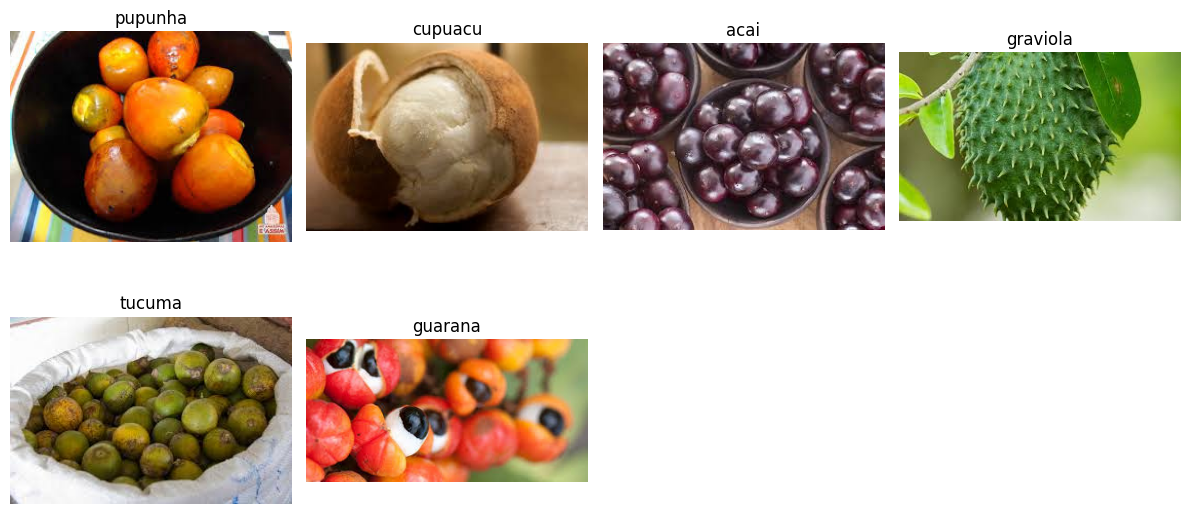

In [3]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

train_dir = "amazon_dataset/FruitinAmazon/train"

# Get class names
classes = os.listdir(train_dir)
print("Classes:", classes)

# Select one random image from each class
images = []
titles = []

for cls in classes:
    cls_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)

    images.append(Image.open(img_path))
    titles.append(cls)

# Plot in grid (2 rows)
plt.figure(figsize=(12, 6))
for i in range(len(images)):
    plt.subplot(2, (len(images)//2)+1, i+1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

Classes: ['guarana', 'pupunha', 'graviola', 'tucuma', 'acai', 'cupuacu']

In [5]:
import tensorflow as tf

img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

# Normalize layer
rescale = tf.keras.layers.Rescaling(1./255)

# Train dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

val_ds = val_ds.map(lambda x, y: (rescale(x), y))


Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [6]:
from tensorflow.keras import layers, models

num_classes = len(classes)

model = models.Sequential([
    # Conv Block 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    # Conv Block 2
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Flatten
    layers.Flatten(),

    # Fully Connected
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),

    # Output
    layers.Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_loss',
    save_best_only=True
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 652ms/step - accuracy: 0.1400 - loss: 1.8280

3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 960ms/step - accuracy: 0.1389 - loss: 1.8417 - val_accuracy: 0.0000e+00 - val_loss: 2.0600
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.3142 - loss: 1.7358

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 482ms/step - accuracy: 0.3333 - loss: 1.6884 - val_accuracy: 0.8333 - val_loss: 1.3032
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.5446 - loss: 1.4468

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 470ms/step - accuracy: 0.5556 - loss: 1.4459 - val_accuracy: 0.7778 - val_loss: 1.2821
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 0.6447 - loss: 1.2175

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 494ms/step - accuracy: 0.6528 - loss: 1.1907 - val_accuracy: 0.8333 - val_loss: 0.9519
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.7141 - loss: 0.9054

...

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 597ms/step - accuracy: 0.7361 - loss: 0.7071 - val_accuracy: 0.8889 - val_loss: 0.5442
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 703ms/step - accuracy: 0.9583 - loss: 0.4387 - val_accuracy: 0.5556 - val_loss: 1.2214
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 575ms/step - accuracy: 0.8756 - loss: 0.3962

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 748ms/step - accuracy: 0.8611 - loss: 0.3846 - val_accuracy: 0.8889 - val_loss: 0.3292
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 416ms/step - accuracy: 0.9583 - loss: 0.2341 - val_accuracy: 0.8333 - val_loss: 0.3706
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 440ms/step - accuracy: 0.9444 - loss: 0.1876 - val_accuracy: 0.8333 - val_loss: 0.5829
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 422ms/step - accuracy: 1.0000 - loss: 0.1080 - val_accuracy: 0.8333 - val_loss: 0.8060
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 424ms/step - accuracy: 1.0000 - loss: 0.0757 - val_accuracy: 0.8333 - val_loss: 0.4418
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 1.0000 - loss: 0.0388

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 490ms/step - accuracy: 1.0000 - loss: 0.0436 - val_accuracy: 0.9444 - val_loss: 0.2161
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 1.0000 - loss: 0.0323

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 466ms/step - accuracy: 1.0000 - loss: 0.0318 - val_accuracy: 0.9444 - val_loss: 0.2007
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 599ms/step - accuracy: 1.0000 - loss: 0.0141 - val_accuracy: 0.8333 - val_loss: 0.2899
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 770ms/step - accuracy: 1.0000 - loss: 0.0077 - val_accuracy: 0.8333 - val_loss: 0.4155
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 615ms/step - accuracy: 1.0000 - loss: 0.0063 - val_accuracy: 0.8333 - val_loss: 0.4535
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 450ms/step - accuracy: 1.0000 - loss: 0.0048 - val_accuracy: 0.8333 - val_loss: 0.4359
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 439ms/step - accuracy: 1.0000 - loss: 0.0037 - val_accuracy: 0.8333 - val_loss: 0.3498
Epoch 20/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 438ms/step - accuracy: 1.0000 - loss: 0.0025 - val_accuracy: 0.8333 - val_loss: 0.2798
Epoch 21/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 425ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 0.8889 - val_lo

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 631ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 0.8889 - val_loss: 0.1981
Epoch 24/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 797ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.8889 - val_loss: 0.2028
Epoch 25/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 428ms/step - accuracy: 1.0000 - loss: 8.8857e-04 - val_accuracy: 0.8333 - val_loss: 0.2159
Epoch 26/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 436ms/step - accuracy: 1.0000 - loss: 7.6923e-04 - val_accuracy: 0.8333 - val_loss: 0.2396
Epoch 27/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 446ms/step - accuracy: 1.0000 - loss: 7.0743e-04 - val_accuracy: 0.8333 - val_loss: 0.2661
Epoch 28/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 435ms/step - accuracy: 1.0000 - loss: 6.5119e-04 - val_accuracy: 0.8333 - val_loss: 0.2856
Epoch 29/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 456ms/step - accuracy: 1.0000 - loss: 6.0002e-04 - val_accuracy: 0.8333 - val_loss: 0.2950
Epoch 30/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 415ms/step - accuracy: 1.0000 - loss: 5.5218e-04 - val_a

In [14]:
test_dir = "amazon_dataset/FruitinAmazon/test"

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(128,128),
    batch_size=32,
    shuffle=False
)

test_ds = test_ds.map(lambda x, y: (rescale(x), y))

loss, acc = model.evaluate(test_ds)
print("Test Accuracy:", acc)

Found 30 files belonging to 6 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.7333 - loss: 0.8416
Test Accuracy: 0.7333333492279053


In [15]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print(classification_report(y_true, y_pred, target_names=classes))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 660ms/step
              precision    recall  f1-score   support

     pupunha       0.67      0.80      0.73         5
     cupuacu       0.50      0.80      0.62         5
        acai       0.83      1.00      0.91         5
    graviola       0.75      0.60      0.67         5
      tucuma       1.00      0.80      0.89         5
     guarana       1.00      0.40      0.57         5

    accuracy                           0.73        30
   macro avg       0.79      0.73      0.73        30
weighted avg       0.79      0.73      0.73        30



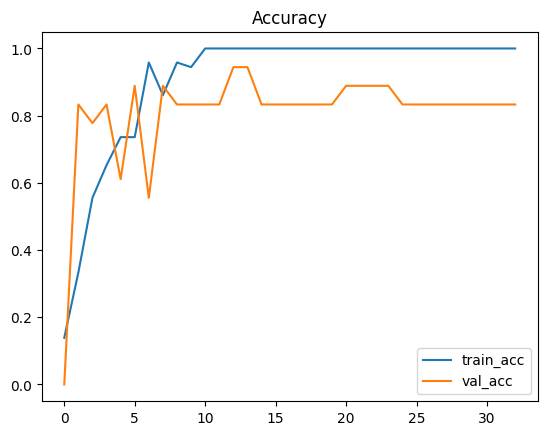

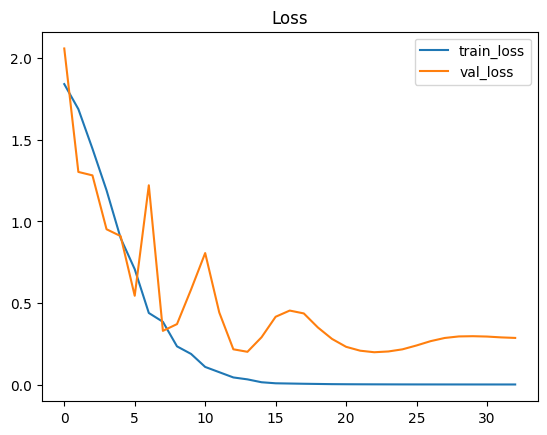

In [16]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss")
plt.show()